# Sanity Check - ERG als Blink-Proxy validieren

Ziel: Prüfen, ob `Erg1/Erg2` verlässlich Blink-Signale enthalten und damit als EOG-Proxy für ICA genutzt werden können.

In der Pipeline werden diese Kanäle als `eog` getaggt, obwohl sie im Datensatz physisch als `Erg1/Erg2` benannt sind.
Dieses Notebook prüft deshalb explizit die EOG-Kanäle mit ERG-Namen.

Dieses Notebook liefert ein 5-Kriterien-Scoring:
- Blink-Rate + Stabilität (Split-Half)
- Blink-Synchronität zwischen Erg1/Erg2 (falls beide vorhanden)
- Blink-SNR im event-locked Signal
- Frontaler EEG-Mitlauf (Korrelation)
- Reduktion blink-lockter EEG-GFP nach ICA (falls cleaned Datei vorhanden)

In [8]:
import importlib
import os
import sys
from pathlib import Path

import mne
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

try:
    from eeg_pipeline import config
except ModuleNotFoundError:
    PIPELINE_DIR = ROOT / 'eeg_pipeline'
    if not PIPELINE_DIR.exists():
        PIPELINE_DIR = ROOT.parent.parent / 'eeg_pipeline'
    if str(PIPELINE_DIR) not in sys.path:
        sys.path.insert(0, str(PIPELINE_DIR))
    config = importlib.import_module('config')

print('Setup erfolgreich')
print(f'Gefundene Subjects in config: {config.SUBJECTS}')

Setup erfolgreich
Gefundene Subjects in config: ['01', '02', '03']


In [9]:
# Manuelle Auswahl fuer diesen Notebook-Run
subject_id = "01"  # z.B. "02"
person = "P2"  # "P1" oder "P2"
if person not in {"P1", "P2"}:
    raise ValueError("person muss P1 oder P2 sein")
os.environ["EEG_SUBJECT"] = subject_id
os.environ["EEG_PERSON"] = person
print(f"Manuell gesetzt: EEG_SUBJECT={os.environ['EEG_SUBJECT']}, EEG_PERSON={os.environ['EEG_PERSON']}")

Manuell gesetzt: EEG_SUBJECT=01, EEG_PERSON=P2


In [10]:
subject_from_env = os.getenv('EEG_SUBJECT')
subject_default = globals().get('subject_id', subject_from_env or (config.SUBJECTS[0] if config.SUBJECTS else None))
if subject_default is None:
    raise ValueError('Kein Subject gefunden. Setze subject_id in der Zelle oder EEG_SUBJECT als Umgebungsvariable.')

subject_id = str(subject_default)
if subject_id.isdigit() and len(subject_id) == 1:
    subject_id = subject_id.zfill(2)

person = globals().get('person', os.getenv('EEG_PERSON', 'P1')).upper()
if person not in ['P1', 'P2']:
    raise ValueError("person muss 'P1' oder 'P2' sein")

before_path = config.OUTPUT_DIR / f"sub-{subject_id}_{person}_filtered.fif"
after_path = config.OUTPUT_DIR / f"sub-{subject_id}_{person}_ica_cleaned.fif"
ica_path = config.QC_DIR / f"sub-{subject_id}_{person}_ica.fif"

print(f'Nutze subject_id={subject_id}, person={person}')
if not before_path.exists():
    raise FileNotFoundError(f'Fehlende Datei: {before_path}')

raw_before = mne.io.read_raw_fif(str(before_path), preload=True)
print('✓ Filtered-Datei geladen')

raw_after = None
if after_path.exists():
    raw_after = mne.io.read_raw_fif(str(after_path), preload=True)
    print('✓ ICA-cleaned Datei geladen')
else:
    print(f'INFO: Keine ICA-cleaned Datei gefunden unter {after_path}')

ica = None
if ica_path.exists():
    ica = mne.preprocessing.read_ica(str(ica_path))
    print('✓ ICA-Datei geladen')
else:
    print(f'INFO: Keine ICA-Datei gefunden unter {ica_path}')

Nutze subject_id=01, person=P2
Opening raw data file c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P2_filtered.fif...
    Range : 0 ... 733799 =      0.000 ...  3668.995 secs
Ready.
Reading 0 ... 733799  =      0.000 ...  3668.995 secs...


C:\Users\BKALYON\AppData\Local\Temp\ipykernel_30936\4112311467.py:22: RuntimeWarning: This filename (c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P2_filtered.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_before = mne.io.read_raw_fif(str(before_path), preload=True)


✓ Filtered-Datei geladen
Opening raw data file c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P2_ica_cleaned.fif...
    Range : 0 ... 733799 =      0.000 ...  3668.995 secs
Ready.
Reading 0 ... 733799  =      0.000 ...  3668.995 secs...


C:\Users\BKALYON\AppData\Local\Temp\ipykernel_30936\4112311467.py:27: RuntimeWarning: This filename (c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P2_ica_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_after = mne.io.read_raw_fif(str(after_path), preload=True)


✓ ICA-cleaned Datei geladen
Reading c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\qc\sub-01_P2_ica.fif ...
Now restoring ICA solution ...
Ready.
✓ ICA-Datei geladen


EOG-Kanaele laut MNE: ['1-Erg1', '1-Erg2']
Davon ERG-benannte EOG-Proxys: ['1-Erg1', '1-Erg2']
Frontale EEG-Kanaele: ['Fp1', 'Fpz', 'Fp2', 'AFz', 'Fz', 'AF3', 'AF4']


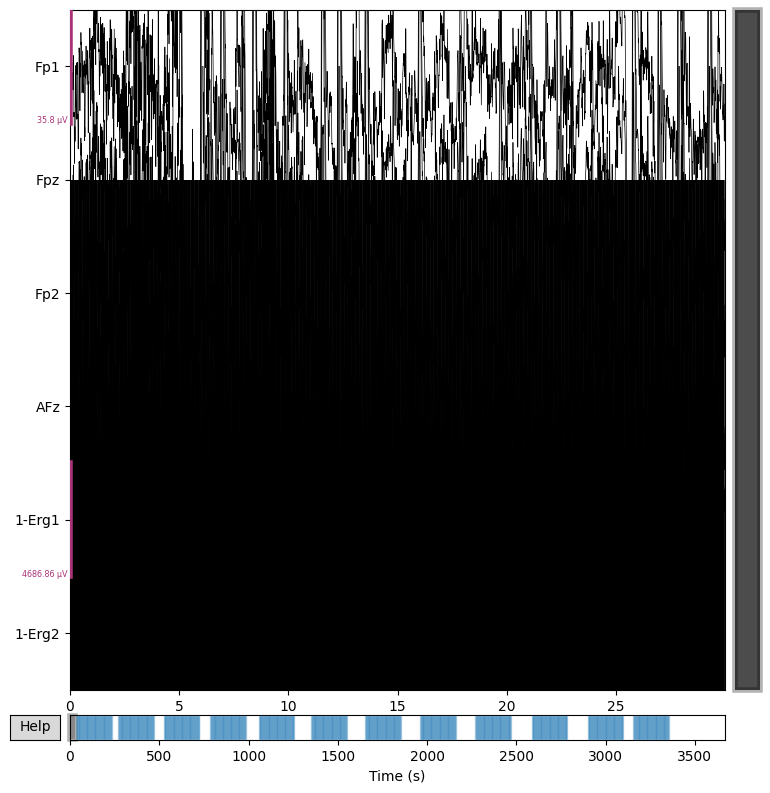

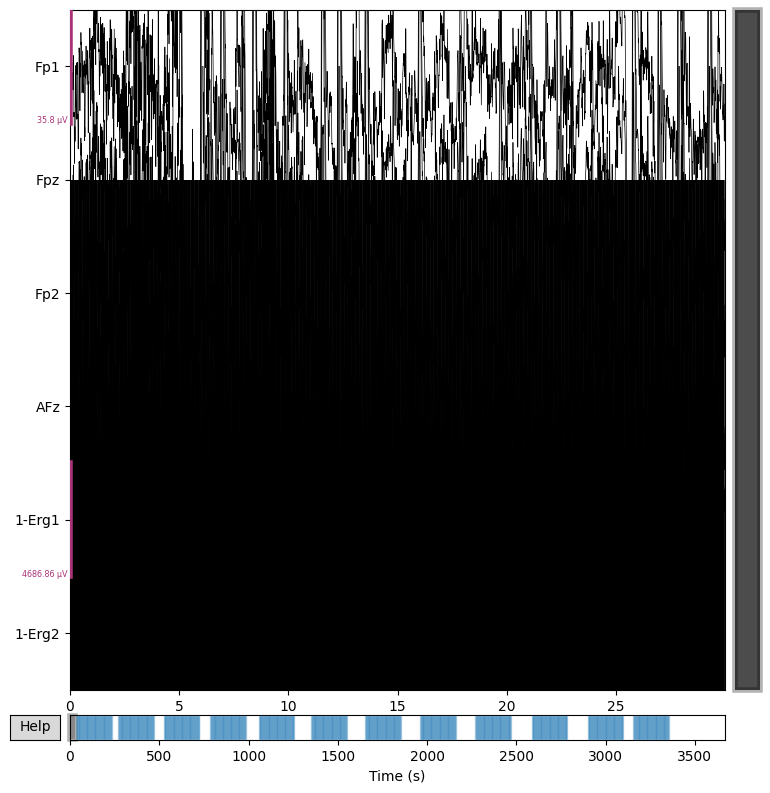

In [11]:
# EOG-Kanaele finden; in diesem Datensatz sind das physisch ERG-Kanaele
eog_picks = mne.pick_types(raw_before.info, eog=True)
eog_names = [raw_before.ch_names[i] for i in eog_picks]
erg_named_eog = [ch for ch in eog_names if ch.lower().endswith(('erg1', 'erg2')) or 'erg' in ch.lower()]
proxy_eog_channels = erg_named_eog if erg_named_eog else eog_names

frontals_pref = ['Fp1', 'Fpz', 'Fp2', 'AFz', 'Fz', 'AF3', 'AF4']
frontal_chs = [ch for ch in frontals_pref if ch in raw_before.ch_names]

print('EOG-Kanaele laut MNE:', eog_names)
print('Davon ERG-benannte EOG-Proxys:', proxy_eog_channels)
print('Frontale EEG-Kanaele:', frontal_chs)

if not proxy_eog_channels:
    raise RuntimeError('Keine EOG-Kanaele gefunden. Pruefe Channel-Typen nach dem Split.')
if not frontal_chs:
    raise RuntimeError('Keine frontalen EEG-Kanaele gefunden. Frontalvergleich nicht moeglich.')

# Kurzer visueller Plausibilitaets-Check
preview_picks = frontal_chs[:4] + proxy_eog_channels[:2]
raw_before.copy().pick(preview_picks).plot(start=0, duration=30, scalings='auto', n_channels=len(preview_picks))

In [12]:
# Blink-Event-Detektion auf jedem EOG-Kanal mit ERG-Namen
event_stats = []
event_dict = {}
duration_min = raw_before.times[-1] / 60.0
sfreq = raw_before.info['sfreq']
half_sample = raw_before.n_times // 2
half_duration_min = duration_min / 2.0

for ch in proxy_eog_channels:
    events = mne.preprocessing.find_eog_events(raw_before, ch_name=ch, verbose=False)
    event_dict[ch] = events
    n_events = len(events)
    rate = n_events / duration_min if duration_min > 0 else np.nan

    n_first = int(np.sum(events[:, 0] < half_sample)) if n_events > 0 else 0
    n_second = n_events - n_first
    rate_first = n_first / half_duration_min if half_duration_min > 0 else np.nan
    rate_second = n_second / half_duration_min if half_duration_min > 0 else np.nan

    rel_diff = np.abs(rate_first - rate_second) / max(rate_first, rate_second, 1e-9)
    stable_split = (3 <= rate_first <= 40) and (3 <= rate_second <= 40) and (rel_diff <= 0.5)

    event_stats.append({
        'channel': ch,
        'n_events': int(n_events),
        'events_per_min': float(rate),
        'rate_first': float(rate_first),
        'rate_second': float(rate_second),
        'split_rel_diff': float(rel_diff),
        'stable_split': bool(stable_split),
    })

    print(
        f"{ch}: {n_events} Events, ~{rate:.1f}/min | "
        f"1stHalf={rate_first:.1f}/min, 2ndHalf={rate_second:.1f}/min, stable={stable_split}"
    )

plausible_channels = [
    s for s in event_stats
    if 3 <= s['events_per_min'] <= 60 and s['n_events'] >= 10
]
stable_channels = [s for s in event_stats if s['stable_split']]

# Synchronitaet zwischen den ersten zwei Proxy-Kanaelen pruefen (typisch Erg1/Erg2)
blink_sync_ratio = np.nan
if len(proxy_eog_channels) >= 2:
    ch_a, ch_b = proxy_eog_channels[:2]
    t_a = event_dict[ch_a][:, 0] / sfreq
    t_b = event_dict[ch_b][:, 0] / sfreq

    if len(t_a) > 0 and len(t_b) > 0:
        max_dt = 0.10  # 100 ms Toleranz
        min_len = min(len(t_a), len(t_b))
        if len(t_a) <= len(t_b):
            nearest = np.min(np.abs(t_a[:, None] - t_b[None, :]), axis=1)
        else:
            nearest = np.min(np.abs(t_b[:, None] - t_a[None, :]), axis=1)
        blink_sync_ratio = float(np.mean(nearest <= max_dt))
        print(f'Synchronitaet {ch_a}<->{ch_b}: {blink_sync_ratio*100:.1f}% innerhalb 100 ms')
    else:
        print(f'Synchronitaet {ch_a}<->{ch_b}: nicht auswertbar (zu wenige Events)')

print('')
print(f'Plausible EOG-Proxy-Kanaele: {[s["channel"] for s in plausible_channels]}')
print(f'Stable Split-Half Kanaele: {[s["channel"] for s in stable_channels]}')

1-Erg1: 2 Events, ~0.0/min | 1stHalf=0.0/min, 2ndHalf=0.0/min, stable=False
1-Erg2: 3 Events, ~0.0/min | 1stHalf=0.0/min, 2ndHalf=0.1/min, stable=False
Synchronitaet 1-Erg1<->1-Erg2: 100.0% innerhalb 100 ms

Plausible EOG-Proxy-Kanaele: []
Stable Split-Half Kanaele: []


Verwende fuer event-locked Analyse: 1-Erg2 (n_events=3)


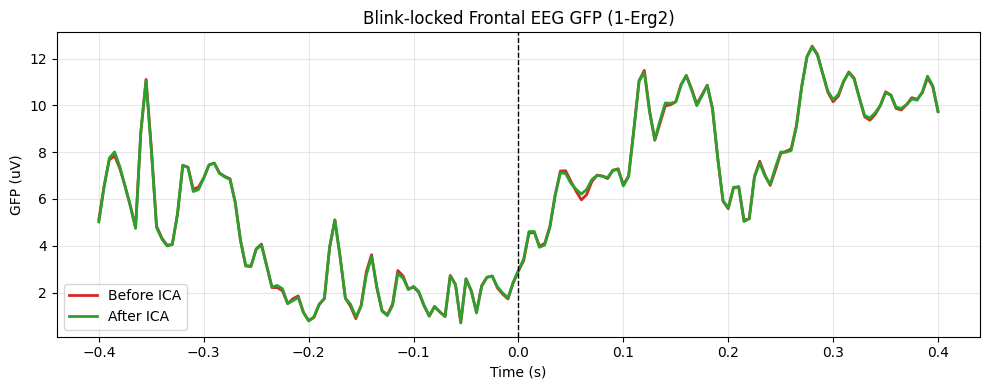

✓ GFP-Plot gespeichert: c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\qc\sub-01_P2_erg_blink_locked_gfp_1-Erg2.png
GFP-Peak before ICA (-50..150 ms): 11.49 uV
GFP-Peak after ICA (-50..150 ms): 11.42 uV
GFP-Reduktion durch ICA: 0.7%
Blink-SNR (peak/noise): 5.02
Frontal-Korrelationen (Proxy vs frontal, 0..200 ms):
  Fp1: r=+0.016
  Fpz: r=+0.028
  Fp2: r=+0.037
  AFz: r=+0.058
  Fz: r=+0.092
  AF3: r=+0.034
  AF4: r=+0.042
Max |r|: 0.092


In [13]:
# Event-locked Frontal-GFP und quantitative Blink-Metriken
if plausible_channels:
    best = sorted(plausible_channels, key=lambda x: x['n_events'], reverse=True)[0]['channel']
else:
    best = max(event_stats, key=lambda x: x['n_events'])['channel']

events = event_dict[best]
eeg_picks = mne.pick_channels(raw_before.ch_names, include=frontal_chs)
print(f'Verwende fuer event-locked Analyse: {best} (n_events={len(events)})')

gfp_peak_before_uv = np.nan
gfp_peak_after_uv = np.nan
gfp_reduction_pct = np.nan
blink_snr = np.nan
max_frontal_abs_corr = np.nan
frontal_corrs = {}

if len(events) > 0 and len(eeg_picks) > 0:
    epochs_before = mne.Epochs(
        raw_before,
        events,
        event_id=998,
        tmin=-0.4,
        tmax=0.4,
        picks=eeg_picks,
        baseline=(-0.2, 0),
        preload=True,
        verbose=False,
    )

    data_before = epochs_before.get_data()
    evoked_before = data_before.mean(axis=0)
    gfp_before_uv = evoked_before.std(axis=0) * 1e6
    times = epochs_before.times

    peak_mask = (times >= -0.05) & (times <= 0.15)
    noise_mask = (times >= -0.35) & (times <= -0.15)

    if np.any(peak_mask):
        gfp_peak_before_uv = float(np.max(gfp_before_uv[peak_mask]))
    if np.any(noise_mask):
        noise_std = float(np.std(gfp_before_uv[noise_mask]))
        blink_snr = gfp_peak_before_uv / max(noise_std, 1e-9)

    # Frontal-Mitlauf: Korrelation Proxy-Signal vs frontaler Evoked-Response im Blinkfenster
    proxy_epochs = mne.Epochs(
        raw_before,
        events,
        event_id=998,
        tmin=-0.4,
        tmax=0.4,
        picks=[best],
        baseline=(-0.2, 0),
        preload=True,
        verbose=False,
    )
    proxy_evoked = proxy_epochs.get_data()[:, 0, :].mean(axis=0)

    corr_mask = (times >= 0.0) & (times <= 0.2)
    if np.any(corr_mask):
        for i, ch in enumerate(frontal_chs):
            x = proxy_evoked[corr_mask]
            y = evoked_before[i, corr_mask]
            if np.std(x) > 1e-12 and np.std(y) > 1e-12:
                r = float(np.corrcoef(x, y)[0, 1])
                frontal_corrs[ch] = r
        if frontal_corrs:
            max_frontal_abs_corr = float(np.max(np.abs(list(frontal_corrs.values()))))

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.plot(times, gfp_before_uv, label='Before ICA', color='tab:red', linewidth=2)

    if raw_after is not None:
        epochs_after = mne.Epochs(
            raw_after,
            events,
            event_id=998,
            tmin=-0.4,
            tmax=0.4,
            picks=eeg_picks,
            baseline=(-0.2, 0),
            preload=True,
            verbose=False,
        )
        evoked_after = epochs_after.get_data().mean(axis=0)
        gfp_after_uv = evoked_after.std(axis=0) * 1e6
        ax.plot(times, gfp_after_uv, label='After ICA', color='tab:green', linewidth=2)

        if np.any(peak_mask):
            gfp_peak_after_uv = float(np.max(gfp_after_uv[peak_mask]))
            gfp_reduction_pct = float((1.0 - (gfp_peak_after_uv / max(gfp_peak_before_uv, 1e-9))) * 100.0)

    ax.axvline(0, color='k', linestyle='--', linewidth=1)
    ax.set_title(f'Blink-locked Frontal EEG GFP ({best})')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('GFP (uV)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()

    out = config.QC_DIR / f'sub-{subject_id}_{person}_erg_blink_locked_gfp_{best}.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    plt.show()

    print(f'✓ GFP-Plot gespeichert: {out}')
    print(f'GFP-Peak before ICA (-50..150 ms): {gfp_peak_before_uv:.2f} uV')
    if np.isfinite(gfp_peak_after_uv):
        print(f'GFP-Peak after ICA (-50..150 ms): {gfp_peak_after_uv:.2f} uV')
        print(f'GFP-Reduktion durch ICA: {gfp_reduction_pct:.1f}%')
    else:
        print('INFO: Keine cleaned Datei, daher keine Before/After Reduktionsmetrik.')
    print(f'Blink-SNR (peak/noise): {blink_snr:.2f}')
    if frontal_corrs:
        print('Frontal-Korrelationen (Proxy vs frontal, 0..200 ms):')
        for ch, r in frontal_corrs.items():
            print(f'  {ch}: r={r:+.3f}')
        print(f'Max |r|: {max_frontal_abs_corr:.3f}')
    else:
        print('INFO: Keine stabilen Frontal-Korrelationen berechenbar.')
else:
    print('Keine nutzbaren Events fuer event-locked Analyse gefunden.')

In [15]:
# 5-Kriterien-Score + GO/NO-GO
ica_support = False
ica_hits = {}

if ica is not None:
    for ch in proxy_eog_channels:
        try:
            bads, scores = ica.find_bads_eog(raw_before, ch_name=ch, verbose=False)
            ica_hits[ch] = {
                'bads': bads,
                'max_abs_score': float(np.max(np.abs(scores))) if len(scores) else np.nan,
            }
            print(f'{ch}: ICA bad candidates={bads[:10]}, max|score|={ica_hits[ch]["max_abs_score"]:.3f}')
        except Exception as exc:
            print(f'{ch}: ICA score-check fehlgeschlagen ({exc})')

    ica_support = any(len(v['bads']) > 0 for v in ica_hits.values())
else:
    print('INFO: Kein ICA-Objekt geladen, ICA-Support wird uebersprungen.')

criterion_rate_stable = len(stable_channels) > 0
criterion_sync = np.isfinite(blink_sync_ratio) and blink_sync_ratio >= 0.70
criterion_snr = np.isfinite(blink_snr) and blink_snr >= 3.0
criterion_frontal = np.isfinite(max_frontal_abs_corr) and max_frontal_abs_corr >= 0.25
criterion_cleanup = np.isfinite(gfp_reduction_pct) and gfp_reduction_pct >= 20.0

criteria = {
    'Rate+Stabilitaet': criterion_rate_stable,
    'Erg1/Erg2 Synchronitaet': criterion_sync,
    'Blink-SNR': criterion_snr,
    'Frontal-Mitlauf': criterion_frontal,
    'ICA Cleanup-Effekt': criterion_cleanup,
}

go_score = int(sum(criteria.values()))

print('')
print('=== Entscheidungshilfe ERG als EOG-Proxy (5 Kriterien) ===')
for name, ok in criteria.items():
    print(f'{name}: {ok}')
print(f'Gesamtscore: {go_score}/5')

if go_score >= 4:
    print('GO: ERG-benannte EOG-Kanaele sind robust genug fuer automatische ICA-Unterstuetzung.')
elif go_score == 3:
    print('BORDERLINE: Nutzbar, aber manuelle ICA-QC (Topomaps/Timecourses) ist verpflichtend.')
else:
    print('NO-GO: Derzeit nicht robust genug als EOG-Proxy. Manuelle Strategie oder andere Referenz nutzen.')

print('')
print('Hinweis zur Synchronitaet: Normales Blinzeln ist meist beidseitig nahezu zeitgleich,')
print('aber kleine Zeitverschiebungen sind normal (Messrauschen, Kanalposition, asymmetrische Lidbewegung).')
print('Gelegentliches Zwinkern kann die Synchronitaet verringern.')

1-Erg1: ICA bad candidates=[np.int64(10), np.int64(15)], max|score|=0.161
1-Erg2: ICA bad candidates=[], max|score|=0.096

=== Entscheidungshilfe ERG als EOG-Proxy (5 Kriterien) ===
Rate+Stabilitaet: False
Erg1/Erg2 Synchronitaet: True
Blink-SNR: True
Frontal-Mitlauf: False
ICA Cleanup-Effekt: False
Gesamtscore: 2/5
NO-GO: Derzeit nicht robust genug als EOG-Proxy. Manuelle Strategie oder andere Referenz nutzen.

Hinweis zur Synchronitaet: Normales Blinzeln ist meist beidseitig nahezu zeitgleich,
aber kleine Zeitverschiebungen sind normal (Messrauschen, Kanalposition, asymmetrische Lidbewegung).
Gelegentliches Zwinkern kann die Synchronitaet verringern.
